Đề 11: Phân cụm trên bộ dữ liệu Digits (Scikit-Learn) — chỉ dùng K-Means
Sử dụng bộ dữ liệu chữ số viết tay load_digits từ Scikit-Learn.
1.	Tải dữ liệu và hiển thị:
-	Kích thước dữ liệu (số mẫu, số đặc trưng)
-	Số lượng mẫu của từng nhãn (0 → 9)
2.	Chuẩn hóa dữ liệu bằng Min-Max Scaling (đưa về [0,1]).
3.	Áp dụng thuật toán K-Means để phân cụm:
-	Chọn số cụm k = 10
-	Thiết lập random state để dễ tái tạo kết quả
4.	Đánh giá kết quả phân cụm bằng Adjusted Rand Index (ARI) so với nhãn thật.
5.	Vẽ Scatter các cụm:
-	Giảm chiều dữ liệu về 2D bằng PCA (chỉ để vẽ):
-	Vẽ biểu đồ scatter (trục PCA1–PCA2), tô màu theo cluster label.


In [1]:
# 1 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA


In [2]:
du_lieu = load_digits()

X = du_lieu.data
y = du_lieu.target

print("Kích thước dữ liệu X:", X.shape)
print("Kích thước nhãn y:", y.shape)

Kích thước dữ liệu X: (1797, 64)
Kích thước nhãn y: (1797,)


In [3]:
bang_nhan = pd.Series(y).value_counts().sort_index()

print(bang_nhan)

0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


In [4]:
chuan_hoa = MinMaxScaler()

X_chuan_hoa = chuan_hoa.fit_transform(X)

In [5]:
#Bước 5: Tạo và huấn luyện KMeans
mo_hinh = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

mo_hinh.fit(X_chuan_hoa)

,n_clusters,10
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [6]:
# Bước 6: Lấy nhãn cụm
cum = mo_hinh.labels_

print(cum)

[3 4 4 ... 4 8 8]


In [7]:
# Bước 7: Đánh giá bằng ARI
ari = adjusted_rand_score(y, cum)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.6646450241172125


In [8]:
# Bước 8: Giảm chiều bằng PCA để vẽ biểu đồ
pca = PCA(n_components=2)

X_2d = pca.fit_transform(X_chuan_hoa)

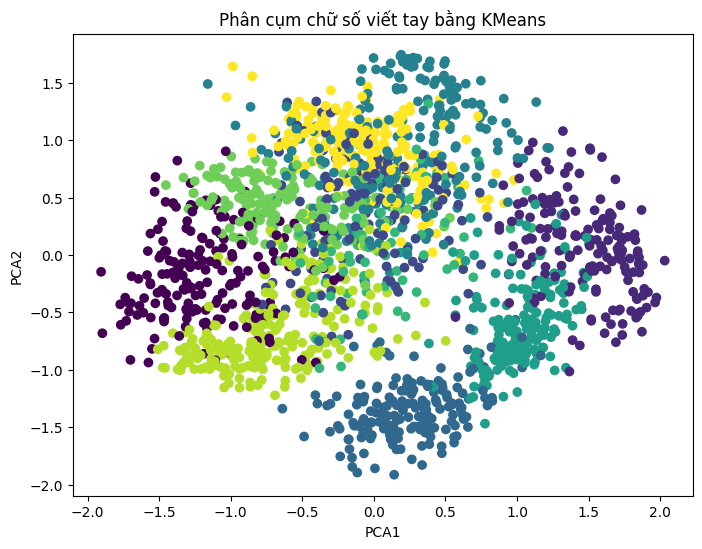

In [9]:
# Bước 9: Vẽ biểu đồ phân cụm
plt.figure(figsize=(8, 6))

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cum)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Phân cụm chữ số viết tay bằng KMeans")

plt.show()